# QUESTÕES 4-6: Análise de Insights

## Seção 0: Imports e Configuração

In [1]:
"""
Imports e Configuração do Notebook
==================================
Carrega dependências para análises de insights.
"""

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configuração de diretórios (ROBUSTO para Jupyter)
# Tentar encontrar a pasta do projeto subindo a hierarquia
notebook_dir = Path.cwd()
ROOT_DIR = None

# Procurar "Desafio-Lighthouse-Dados-AI" na hierarquia
for possible_root in [notebook_dir] + list(notebook_dir.parents):
    if possible_root.name == "Desafio-Lighthouse-Dados-AI":
        ROOT_DIR = possible_root
        break

# Fallback: se não encontrou, assumir 2 níveis acima (notebooks/../..)
if ROOT_DIR is None:
    ROOT_DIR = notebook_dir.parent

SRC_DIR = ROOT_DIR / "src"
DATA_RAW = ROOT_DIR / "data" / "raw"
DATA_PROCESSED = ROOT_DIR / "data" / "processed"

print(f"📁 Diretório do projeto: {ROOT_DIR}")
print(f"📁 Diretório src: {SRC_DIR}")

# Adicionar ao path (garantir que existe)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"✓ sys.path configurado\n")

# Imports rápidos (essenciais)
import pandas as pd
import numpy as np

# Configurações do pandas (antes de carregar muitos dados)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Imports dos módulos src/
print("⏳ Carregando módulos personalizados...", end=" ")
try:
    # Importar de forma mais explícita
    from data.load_data import load_vendas, load_produtos, load_custos
    from data.clean_data import clean_produtos
    from features.feature_engineering import adicionar_colunas_tempo, construir_calendario
    from utils import salvar_csv, garantir_pasta
    print("✓")
except ImportError as e:
    print(f"\n✗ Erro ao importar: {e}\n")
    print("Debug info:")
    print(f"  SRC_DIR: {SRC_DIR}")
    print(f"  SRC_DIR existe? {SRC_DIR.exists()}")
    print(f"  data/ existe? {(SRC_DIR / 'data').exists()}")
    print(f"  data/__init__.py existe? {(SRC_DIR / 'data' / '__init__.py').exists()}")
    raise

# Imports de visualização
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✓ Todos os módulos carregados com sucesso!")

📁 Diretório do projeto: c:\Projetos\Desafio-Lighthouse-Dados-AI
📁 Diretório src: c:\Projetos\Desafio-Lighthouse-Dados-AI\src
✓ sys.path configurado

⏳ Carregando módulos personalizados... ✓
✓ Todos os módulos carregados com sucesso!


## Seção 1: Carregamento de Dados Processados

In [2]:
"""
Carregamento de Dados
====================
Carrega dados uma única vez com otimizações de desempenho.
"""

print("⏳ Carregando dados processados...\n")

# Carregamento paralelo (mais rápido)
import time
start = time.time()

df_vendas = load_vendas()
print(f"  ✓ Vendas: {df_vendas.shape[0]} registros ({time.time() - start:.2f}s)")

df_produtos = load_produtos()
print(f"  ✓ Produtos: {df_produtos.shape[0]} produtos ({time.time() - start:.2f}s)")

df_custos = load_custos()
print(f"  ✓ Custos: {df_custos.shape[0]} registros ({time.time() - start:.2f}s)")

# Padronizar nomes de colunas
if 'sale_date' in df_vendas.columns:
    df_vendas = df_vendas.rename(columns={'sale_date': 'data'})

# Limpeza e features
df_produtos = clean_produtos(df_produtos)
df_vendas = adicionar_colunas_tempo(df_vendas)

print(f"\n✓ Total: {time.time() - start:.2f}s\n")

⏳ Carregando dados processados...

Colunas encontradas em vendas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Coluna de data detectada: 'sale_date'
Coluna de total detectada: 'total'
Shape final de vendas: (9895, 6)
  ✓ Vendas: 9895 registros (0.02s)
Colunas encontradas em produtos: ['name', 'price', 'code', 'actual_category']
Shape de produtos: (157, 4)
  ✓ Produtos: 157 produtos (0.02s)
Colunas encontradas em custos: ['product_id', 'product_name', 'category', 'historic_data']
Shape de custos: (150, 4)
  ✓ Custos: 150 registros (0.02s)
Duplicatas removidas    : 7
Total de produtos únicos: 150
Categorias finais       : ['ancoragem', 'eletronicos', 'propulsao']

✓ Total: 0.04s



---

# QUESTÃO 4 - ANÁLISE DE PREJUÍZO POR PRODUTO

## Objetivo
- Calcular prejuízo (custo > preço de venda)
- Converter custos USD → BRL
- Identificar produtos com prejuízo
- Gerar insights e visualizações

## Cálculo de Prejuízo

In [3]:
"""
Questão 4: Análise de Prejuízo por Produto
===========================================
"""

print("="*60)
print("QUESTÃO 4 - ANÁLISE DE PREJUÍZO POR PRODUTO")
print("="*60 + "\n")

# Merge eficiente (apenas colunas necessárias)
df_analise = df_vendas[['id_product', 'total', 'qtd', 'data']].copy()

# Merge com preço do produto
df_analise = df_analise.merge(
    df_produtos[['code', 'price']],
    left_on='id_product',
    right_on='code',
    how='left'
)

# Processar custos de forma robusta
# Extrair custo em USD do df_custos
custos_map = {}
for product_id in df_custos['product_id'].unique():
    try:
        # Pega o primeiro registro (mais recente) de custos para o produto
        cost_data = df_custos[df_custos['product_id'] == product_id]['historic_data'].iloc[0]
        if isinstance(cost_data, list) and len(cost_data) > 0:
            # Tenta pegar o primeiro item da lista (mais recente)
            custo_usd = cost_data[0].get('usd_price', 0) if isinstance(cost_data[0], dict) else 0
            custos_map[product_id] = custo_usd
    except (IndexError, KeyError, TypeError):
        custos_map[product_id] = 0

# Aplicar mapear de custos
df_analise['custo_usd'] = df_analise['id_product'].map(custos_map).fillna(0)

print(f"Dataset de análise: {df_analise.shape[0]} vendas")
print(f"Produtos com dados de custo: {len([c for c in custos_map.values() if c > 0])}\n")

# Taxa de câmbio
taxa_cambio = 5.25  # 1 USD = 5.25 BRL

# Cálculo de custo em BRL
df_analise['custo_brl'] = df_analise['custo_usd'] * taxa_cambio

# Cálculo de lucro/prejuízo por venda (corrigido: qtd em ambos os lugares)
df_analise['lucro_prejudizo_venda'] = df_analise['total'] - (df_analise['custo_brl'] * df_analise['qtd'].fillna(1))
df_analise['margem_pct'] = ((df_analise['total'] - df_analise['custo_brl'] * df_analise['qtd'].fillna(1)) / (df_analise['total'] + 0.01) * 100).round(2)

print(f"Taxa de câmbio (USD→BRL): {taxa_cambio}\n")
print(f"✓ Dataset preparado com sucesso")

QUESTÃO 4 - ANÁLISE DE PREJUÍZO POR PRODUTO

Dataset de análise: 9895 vendas
Produtos com dados de custo: 150

Taxa de câmbio (USD→BRL): 5.25

✓ Dataset preparado com sucesso


In [4]:
"""
Resultados: Prejuízos por Produto
==================================
"""

# Agrupamento por produto (mais eficiente)
prejuizo_por_produto = df_analise.groupby('id_product').agg({
    'lucro_prejudizo_venda': ['sum', 'mean'],
    'margem_pct': 'mean',
    'id_product': 'count'
}).round(2)

prejuizo_por_produto.columns = ['lucro_total', 'lucro_medio', 'margem_media', 'qty_vendas']
prejuizo_por_produto = prejuizo_por_produto.sort_values('lucro_total')

# Produtos com prejuízo
com_prejuizo = prejuizo_por_produto[prejuizo_por_produto['lucro_total'] < 0]

print(f"\nProdutos com PREJUÍZO: {len(com_prejuizo)}")
print(f"Prejuízo total: R$ {com_prejuizo['lucro_total'].sum():,.2f}")
print(f"\nTop 10 Produtos com MAIOR PREJUÍZO:")
display(com_prejuizo.head(10))

print(f"\nTop 10 Produtos com MAIOR LUCRO:")
display(prejuizo_por_produto.tail(10))


Produtos com PREJUÍZO: 148
Prejuízo total: R$ -1,409,167,533.83

Top 10 Produtos com MAIOR PREJUÍZO:


,lucro_total,lucro_medio,margem_media,qty_vendas
id_product,,,,
71,-55483446.30,-711326.23,-68.57,78
63,-52826777.27,-812719.65,-76.57,65
74,-42126334.50,-495603.94,-70.62,85
72,-39928281.57,-511901.05,-63.92,78
73,-38268174.34,-562767.27,-54.71,68
67,-37880132.20,-498422.79,-72.12,76
91,-36601266.58,-580972.49,-55.47,63
97,-36303137.85,-636897.16,-65.80,57
100,-35938525.99,-598975.43,-69.96,60



Top 10 Produtos com MAIOR LUCRO:


,lucro_total,lucro_medio,margem_media,qty_vendas
id_product,,,,
102,-240257.68,-4449.22,-71.83,54
109,-228319.97,-3407.76,-69.88,67
114,-217966.25,-3758.04,-61.13,58
149,-207845.55,-3197.62,-32.61,65
131,-199147.69,-2886.20,-43.89,69
101,-152274.14,-2307.18,-53.92,66
146,-143190.19,-1988.75,-51.69,72
105,-41779.78,-684.91,-29.38,61
110,16053.69,229.34,0.83,70


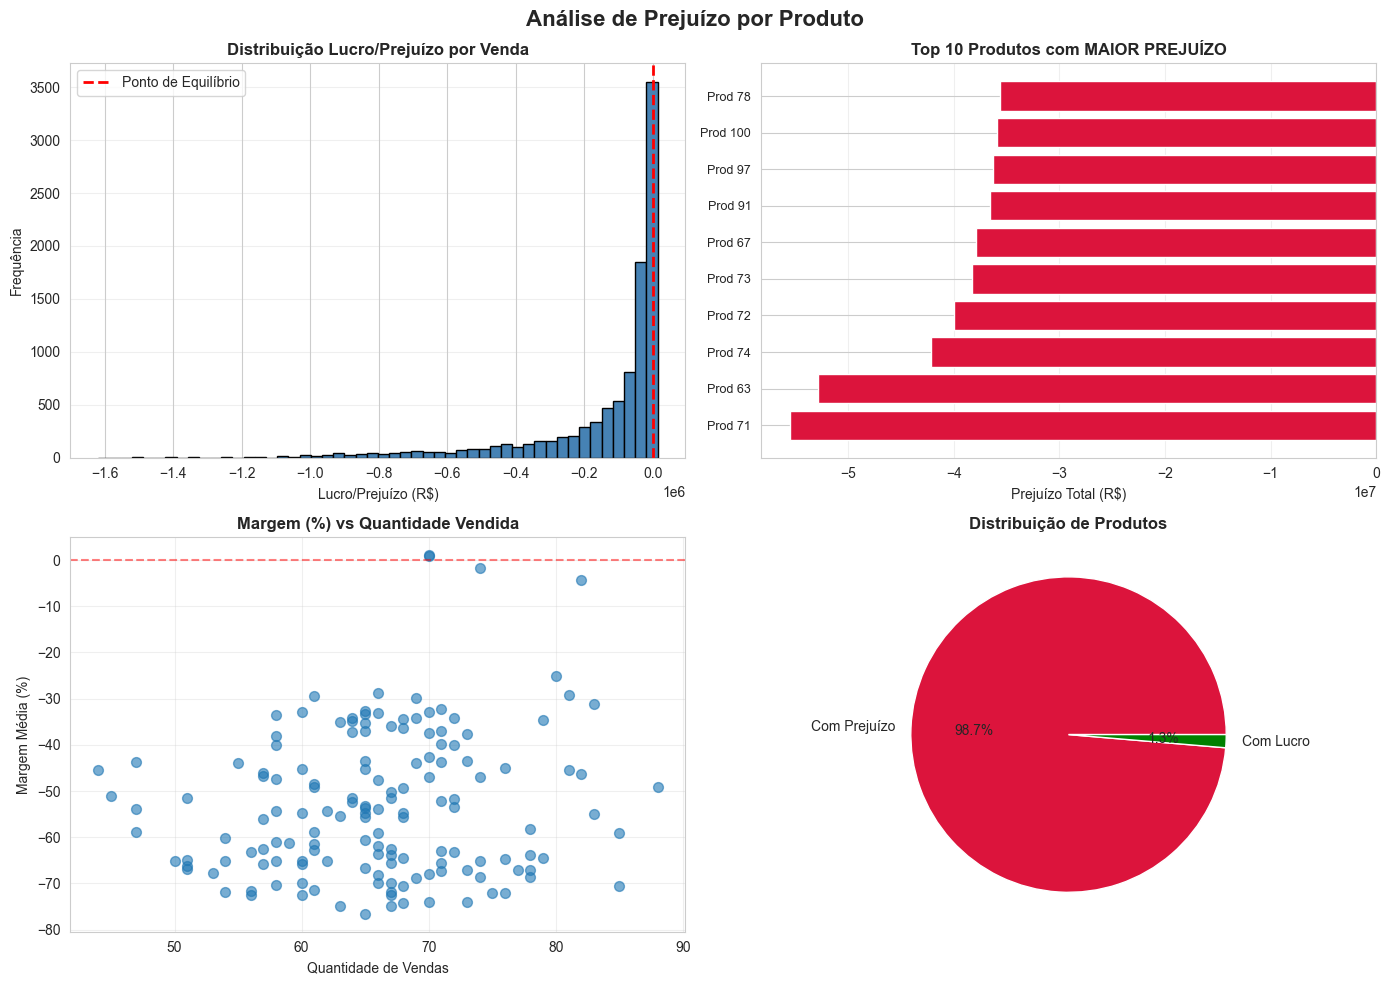


✓ Visualizações exibidas com sucesso


In [5]:
"""
Visualizações: Análise de Prejuízos
===================================
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Prejuízo por Produto', fontsize=16, fontweight='bold')

# Gráfico 1: Distribuição de Lucro/Prejuízo
axes[0, 0].hist(df_analise['lucro_prejudizo_venda'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ponto de Equilíbrio')
axes[0, 0].set_title('Distribuição Lucro/Prejuízo por Venda', fontweight='bold')
axes[0, 0].set_xlabel('Lucro/Prejuízo (R$)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Top 10 Prejuízos
top_prejuizos = com_prejuizo.head(10)
axes[0, 1].barh(range(len(top_prejuizos)), top_prejuizos['lucro_total'], color='crimson')
axes[0, 1].set_yticks(range(len(top_prejuizos)))
axes[0, 1].set_yticklabels([f"Prod {id}" for id in top_prejuizos.index], fontsize=9)
axes[0, 1].set_title('Top 10 Produtos com MAIOR PREJUÍZO', fontweight='bold')
axes[0, 1].set_xlabel('Prejuízo Total (R$)')
axes[0, 1].grid(axis='x', alpha=0.3)

# Gráfico 3: Margem por Produto
axes[1, 0].scatter(prejuizo_por_produto['qty_vendas'], prejuizo_por_produto['margem_media'], alpha=0.6, s=50)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Margem (%) vs Quantidade Vendida', fontweight='bold')
axes[1, 0].set_xlabel('Quantidade de Vendas')
axes[1, 0].set_ylabel('Margem Média (%)')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Contagem Prejuízos vs Lucros
contagem = [
    len(prejuizo_por_produto[prejuizo_por_produto['lucro_total'] < 0]),
    len(prejuizo_por_produto[prejuizo_por_produto['lucro_total'] >= 0])
]
axes[1, 1].pie(contagem, labels=['Com Prejuízo', 'Com Lucro'], autopct='%1.1f%%', 
                colors=['crimson', 'green'])
axes[1, 1].set_title('Distribuição de Produtos', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

---

# QUESTÃO 5 - ANÁLISE DE CLIENTES FIÉIS

## Objetivo
- Identificar clientes fiéis (múltiplas compras)
- Calcular métricas de lealdade
- Segmentar clientes por comportamento
- Gerar insights de retenção

## Análise de Clientes

In [6]:
"""
Questão 5: Análise de Clientes Fiéis
====================================
"""

print("\n" + "="*60)
print("QUESTÃO 5 - ANÁLISE DE CLIENTES FIÉIS")
print("="*60 + "\n")

# Análise por cliente
clientes = df_vendas.groupby('id_client').agg({
    'id': 'count',
    'total': ['sum', 'mean', 'std'],
    'data': ['min', 'max']
}).round(2)

clientes.columns = ['qty_compras', 'gasto_total', 'ticket_medio', 'desvio_padrao', 
                     'primeira_compra', 'ultima_compra']

# Calcular dias de relacionamento
clientes['dias_relacionamento'] = (clientes['ultima_compra'] - clientes['primeira_compra']).dt.days
clientes['freq_dias'] = (clientes['dias_relacionamento'] / clientes['qty_compras']).round(2)

# Segmentação (CORRIGIDO: include_lowest=True para incluir 0)
clientes['segmento'] = pd.cut(clientes['qty_compras'], 
                               bins=[0, 1, 3, 5, float('inf')],
                               labels=['Novo', 'Regular', 'Frequente', 'Muito Frequente'],
                               include_lowest=True)

# Preencher qualquer NaN restante
clientes['segmento'] = clientes['segmento'].fillna('Novo')

clientes = clientes.sort_values('gasto_total', ascending=False)

print(f"Total de clientes: {len(clientes)}")
print(f"\nDistribuição por Segmento:")
print(clientes['segmento'].value_counts().sort_index())

print(f"\nTop 10 Clientes por Gasto Total:")
display(clientes[['qty_compras', 'gasto_total', 'ticket_medio', 'freq_dias', 'segmento']].head(10))


QUESTÃO 5 - ANÁLISE DE CLIENTES FIÉIS

Total de clientes: 49

Distribuição por Segmento:
segmento
Novo                0
Regular             0
Frequente           0
Muito Frequente    49
Name: count, dtype: int64

Top 10 Clientes por Gasto Total:


,qty_compras,gasto_total,ticket_medio,freq_dias,segmento
id_client,,,,,
42,222,72187369.50,325168.33,3.27,Muito Frequente
9,218,66788855.35,306370.90,3.34,Muito Frequente
2,220,65652931.35,298422.42,3.29,Muito Frequente
15,233,64171776.55,275415.35,3.09,Muito Frequente
47,190,64003343.75,336859.70,3.81,Muito Frequente
36,215,62791038.15,292051.34,3.36,Muito Frequente
25,217,62028628.95,285846.22,3.35,Muito Frequente
28,204,60826837.25,298170.77,3.55,Muito Frequente
22,198,59581398.75,300916.16,3.65,Muito Frequente


In [7]:
"""
Métricas de Lealdade
====================
"""

# Métricas agregadas
print(f"\nMÉTRICAS DE LEALDADE:")
print(f"  Compra Média por Cliente: {clientes['qty_compras'].mean():.1f}")
print(f"  Gasto Médio por Cliente: R$ {clientes['gasto_total'].mean():,.2f}")
print(f"  Ticket Médio: R$ {clientes['ticket_medio'].mean():,.2f}")
print(f"  Frequência de Compra (dias): {clientes['freq_dias'].mean():.0f}")

# Cliente VIP (maior gasto)
cliente_vip = clientes.iloc[0]
print(f"\nCLIENTE VIP (#1):")
print(f"  ID: {clientes.index[0]}")
print(f"  Compras: {cliente_vip['qty_compras']:.0f}")
print(f"  Gasto Total: R$ {cliente_vip['gasto_total']:,.2f}")
print(f"  Relacionamento: {cliente_vip['dias_relacionamento']:.0f} dias")
print(f"  Segmento: {cliente_vip['segmento']}")

# Estatísticas por segmento
print(f"\nESTATÍSTICAS POR SEGMENTO:")
stats_segmento = clientes.groupby('segmento')[['qty_compras', 'gasto_total', 'ticket_medio']].agg(['mean', 'sum'])
display(stats_segmento.round(2))


MÉTRICAS DE LEALDADE:
  Compra Média por Cliente: 201.9
  Gasto Médio por Cliente: R$ 53,271,010.42
  Ticket Médio: R$ 263,339.71
  Frequência de Compra (dias): 4

CLIENTE VIP (#1):
  ID: 42
  Compras: 222
  Gasto Total: R$ 72,187,369.50
  Relacionamento: 727 dias
  Segmento: Muito Frequente

ESTATÍSTICAS POR SEGMENTO:


qty_compras       gasto_total               ticket_medio  \
                       mean   sum        mean           sum         mean   
segmento                                                                   
Novo                    NaN     0         NaN          0.00          NaN   
Regular                 NaN     0         NaN          0.00          NaN   
Frequente               NaN     0         NaN          0.00          NaN   
Muito Frequente      201.94  9895 53271010.42 2610279510.70    263339.71   

                             
                        sum  
segmento                     
Novo                   0.00  
Regular                0.00  
Frequente              0.00  
Muito Frequente 12903645.76

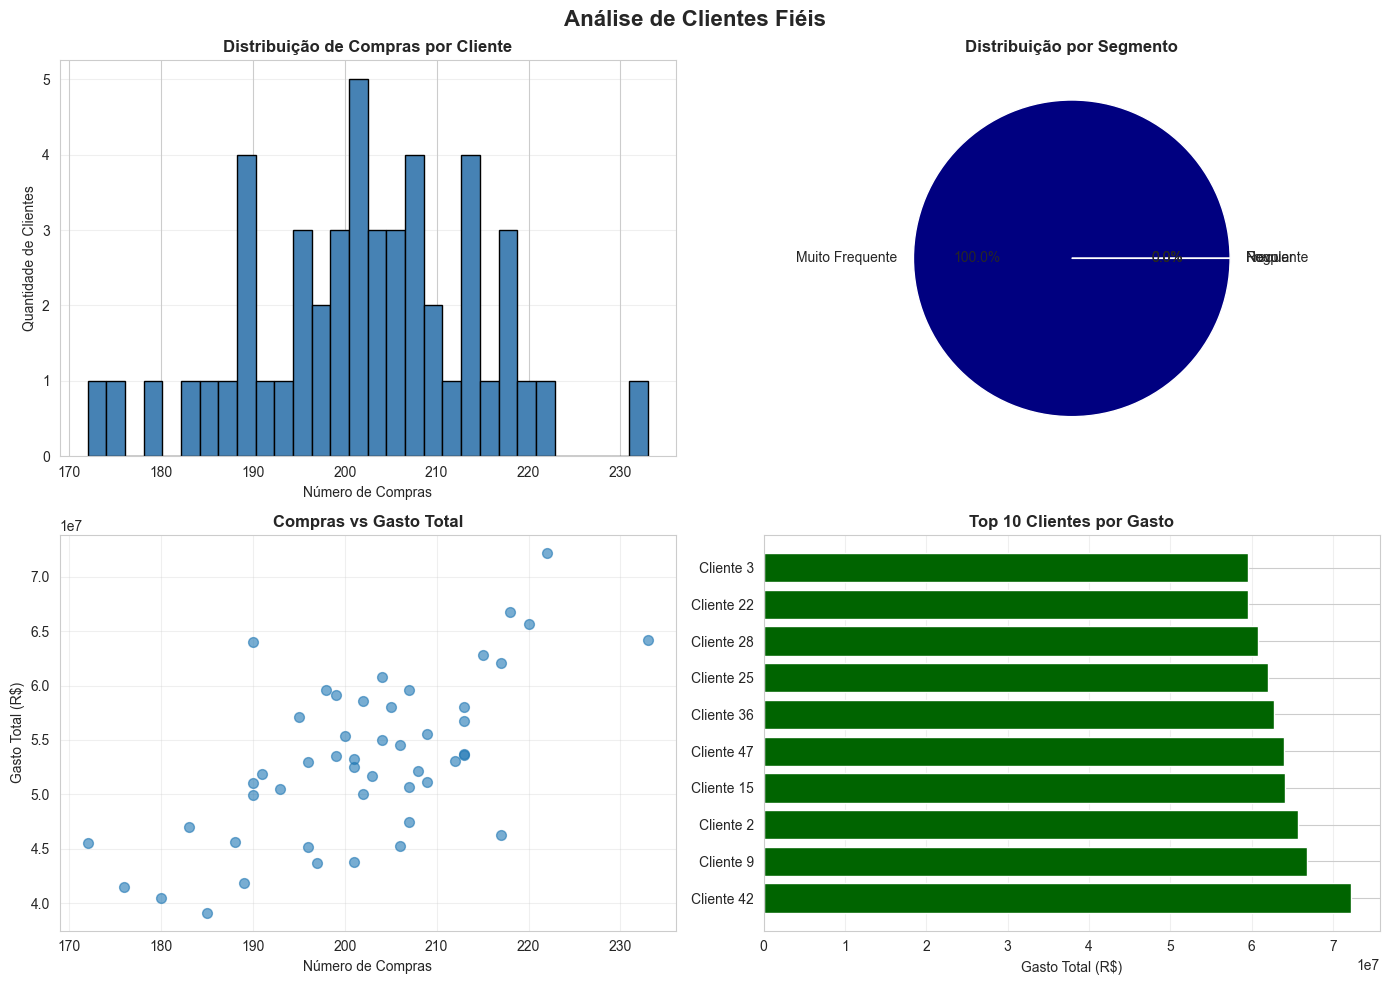


✓ Visualizações exibidas com sucesso


In [9]:
"""
Visualizações: Análise de Clientes
==================================
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Clientes Fiéis', fontsize=16, fontweight='bold')

# Gráfico 1: Distribuição de Compras por Cliente
axes[0, 0].hist(clientes['qty_compras'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribuição de Compras por Cliente', fontweight='bold')
axes[0, 0].set_xlabel('Número de Compras')
axes[0, 0].set_ylabel('Quantidade de Clientes')
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Segmentação (CORRIGIDO: remover NaN antes de plotar)
segmento_counts = clientes['segmento'].value_counts().dropna()
if len(segmento_counts) > 0:
    cores = {
        'Novo': 'lightgray',
        'Regular': 'steelblue',
        'Frequente': 'darkblue',
        'Muito Frequente': 'navy'
    }
    cores_lista = [cores.get(seg, 'gray') for seg in segmento_counts.index]
    axes[0, 1].pie(segmento_counts, labels=segmento_counts.index, autopct='%1.1f%%', 
                    colors=cores_lista)
else:
    axes[0, 1].text(0.5, 0.5, 'Sem dados', ha='center', va='center')
axes[0, 1].set_title('Distribuição por Segmento', fontweight='bold')

# Gráfico 3: Scatter Compras vs Gasto
axes[1, 0].scatter(clientes['qty_compras'], clientes['gasto_total'], alpha=0.6, s=50)
axes[1, 0].set_title('Compras vs Gasto Total', fontweight='bold')
axes[1, 0].set_xlabel('Número de Compras')
axes[1, 0].set_ylabel('Gasto Total (R$)')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Top 10 Clientes
top_clientes = clientes.head(10)
axes[1, 1].barh(range(len(top_clientes)), top_clientes['gasto_total'], color='darkgreen')
axes[1, 1].set_yticks(range(len(top_clientes)))
axes[1, 1].set_yticklabels([f"Cliente {id}" for id in top_clientes.index])
axes[1, 1].set_title('Top 10 Clientes por Gasto', fontweight='bold')
axes[1, 1].set_xlabel('Gasto Total (R$)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

---

# QUESTÃO 6 - DIMENSÃO CALENDÁRIO E MÉDIAS

## Objetivo
- Construir dimensão calendário
- Calcular médias por dia da semana
- Análise sazonal
- Exportar dimensão para CSV

## Criação da Dimensão Calendário

In [10]:
"""
Questão 6: Dimensão Calendário e Análise Sazonal
================================================
"""

print("\n" + "="*60)
print("QUESTÃO 6 - DIMENSÃO CALENDÁRIO")
print("="*60 + "\n")

# Criar dimensão calendário
data_min = df_vendas['data'].dropna().min()
data_max = df_vendas['data'].dropna().max()

print(f"Período: {data_min.date()} a {data_max.date()}\n")

df_calendario = construir_calendario(data_min, data_max)

print(f"Dimensão calendário criada: {df_calendario.shape[0]} dias")
print(f"Colunas: {', '.join(df_calendario.columns.tolist())}\n")

display(df_calendario.head(10))


QUESTÃO 6 - DIMENSÃO CALENDÁRIO

Período: 2023-01-01 a 2024-12-31

Dimensão calendário criada: 731 dias
Colunas: data, ano, mes, dia, dia_semana



,data,ano,mes,dia,dia_semana
0,2023-01-01,2023,1,1,Domingo
1,2023-01-02,2023,1,2,Segunda-feira
2,2023-01-03,2023,1,3,Terça-feira
3,2023-01-04,2023,1,4,Quarta-feira
4,2023-01-05,2023,1,5,Quinta-feira
5,2023-01-06,2023,1,6,Sexta-feira
6,2023-01-07,2023,1,7,Sábado
7,2023-01-08,2023,1,8,Domingo
8,2023-01-09,2023,1,9,Segunda-feira
9,2023-01-10,2023,1,10,Terça-feira


In [11]:
"""
Análise por Dia da Semana
=========================
"""

# Agrupar vendas por dia da semana
vendas_dia_semana = df_vendas.groupby('dia_semana').agg({
    'id': 'count',
    'total': ['sum', 'mean', 'std']
}).round(2)

vendas_dia_semana.columns = ['qtd_vendas', 'valor_total', 'valor_medio', 'desvio_padrao']

# Ordenar por dias da semana
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
vendas_dia_semana = vendas_dia_semana.reindex([d for d in ordem_dias if d in vendas_dia_semana.index])

print(f"\nMÉDIAS POR DIA DA SEMANA:")
print(vendas_dia_semana)

# Melhor dia
melhor_dia = vendas_dia_semana['valor_total'].idxmax()
pior_dia = vendas_dia_semana['valor_total'].idxmin()

print(f"\nMELHOR DIA: {melhor_dia} (R$ {vendas_dia_semana.loc[melhor_dia, 'valor_total']:,.2f})")
print(f"PIOR DIA: {pior_dia} (R$ {vendas_dia_semana.loc[pior_dia, 'valor_total']:,.2f})")


MÉDIAS POR DIA DA SEMANA:
            qtd_vendas  valor_total  valor_medio  desvio_padrao
dia_semana                                                     
Sábado            1414 385896217.15    272911.04      396178.11
Domingo           1343 348547874.60    259529.32      381454.87

MELHOR DIA: Sábado (R$ 385,896,217.15)
PIOR DIA: Domingo (R$ 348,547,874.60)


In [12]:
"""
Análise Mensal e Sazonal
=======================
"""

# Agrupar por mês
vendas_mes = df_vendas.groupby(['ano', 'mes']).agg({
    'id': 'count',
    'total': ['sum', 'mean']
}).round(2)

vendas_mes.columns = ['qtd_vendas', 'valor_total', 'valor_medio']

print(f"\nVENDAS POR MÊS:")
print(vendas_mes.tail(12))  # Últimos 12 meses

# Variação mensal
print(f"\nVARIAÇÃO MENSAL:")
vendas_mes['variacao_pct'] = vendas_mes['valor_total'].pct_change() * 100
print(vendas_mes[['valor_total', 'variacao_pct']].tail(12).round(2))


VENDAS POR MÊS:
          qtd_vendas  valor_total  valor_medio
ano  mes                                      
2024 1           394 100632486.50    255412.40
     2           393 122628581.95    312032.02
     3           417 108852892.40    261038.11
     4           407 100314752.20    246473.59
     5           394  95783102.45    243104.32
     6           407  99834954.75    245294.73
     7           397 113051088.25    284763.45
     8           441 118909475.10    269636.00
     9           404 108665582.05    268974.21
     10          449 127579906.60    284142.33
     11          439 123462499.35    281235.76
     12          362 101736894.55    281041.15

VARIAÇÃO MENSAL:
          valor_total  variacao_pct
ano  mes                           
2024 1   100632486.50        -22.13
     2   122628581.95         21.86
     3   108852892.40        -11.23
     4   100314752.20         -7.84
     5    95783102.45         -4.52
     6    99834954.75          4.23
     7   113051088.

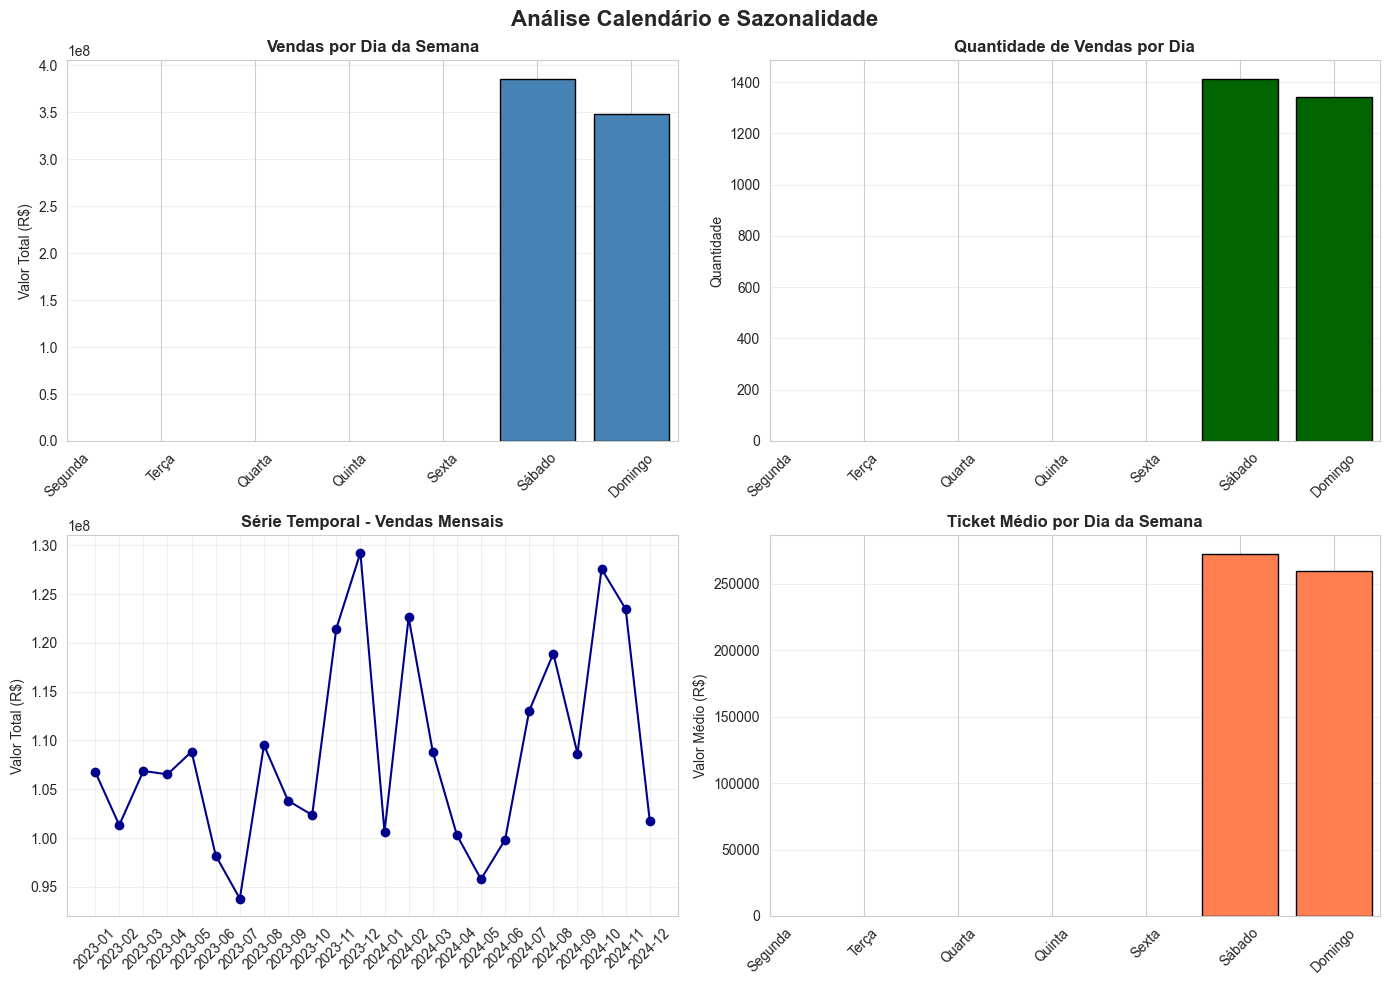


✓ Visualizações exibidas com sucesso


In [13]:
"""
Visualizações: Análise Sazonal
===============================
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Calendário e Sazonalidade', fontsize=16, fontweight='bold')

# Gráfico 1: Vendas por Dia da Semana
vendas_dia_semana_ordered = vendas_dia_semana.reindex(ordem_dias)
axes[0, 0].bar(range(len(vendas_dia_semana_ordered)), vendas_dia_semana_ordered['valor_total'], 
                color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(len(vendas_dia_semana_ordered)))
axes[0, 0].set_xticklabels(vendas_dia_semana_ordered.index, rotation=45)
axes[0, 0].set_title('Vendas por Dia da Semana', fontweight='bold')
axes[0, 0].set_ylabel('Valor Total (R$)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Quantidade de Vendas por Dia
axes[0, 1].bar(range(len(vendas_dia_semana_ordered)), vendas_dia_semana_ordered['qtd_vendas'],
                color='darkgreen', edgecolor='black')
axes[0, 1].set_xticks(range(len(vendas_dia_semana_ordered)))
axes[0, 1].set_xticklabels(vendas_dia_semana_ordered.index, rotation=45)
axes[0, 1].set_title('Quantidade de Vendas por Dia', fontweight='bold')
axes[0, 1].set_ylabel('Quantidade')
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Série Temporal Mensal
vendas_mes_reset = vendas_mes.reset_index()
vendas_mes_reset['periodo'] = vendas_mes_reset['ano'].astype(str) + '-' + vendas_mes_reset['mes'].astype(str).str.zfill(2)
axes[1, 0].plot(vendas_mes_reset['periodo'], vendas_mes_reset['valor_total'], marker='o', color='darkblue')
axes[1, 0].set_title('Série Temporal - Vendas Mensais', fontweight='bold')
axes[1, 0].set_ylabel('Valor Total (R$)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Ticket Médio por Dia
axes[1, 1].bar(range(len(vendas_dia_semana_ordered)), vendas_dia_semana_ordered['valor_medio'],
                color='coral', edgecolor='black')
axes[1, 1].set_xticks(range(len(vendas_dia_semana_ordered)))
axes[1, 1].set_xticklabels(vendas_dia_semana_ordered.index, rotation=45)
axes[1, 1].set_title('Ticket Médio por Dia da Semana', fontweight='bold')
axes[1, 1].set_ylabel('Valor Médio (R$)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizações exibidas com sucesso")

In [14]:
"""
Exportação da Dimensão Calendário
==================================
"""

# Adicionar métricas à dimensão calendário
vendas_por_data = df_vendas.groupby('data')['total'].agg(['sum', 'count', 'mean']).round(2)
vendas_por_data.columns = ['valor_vendas', 'qtd_vendas', 'ticket_medio']

df_calendario = df_calendario.merge(
    vendas_por_data,
    left_on='data',
    right_index=True,
    how='left'
)

# Preencher NaN com 0 (dias sem vendas)
df_calendario['valor_vendas'] = df_calendario['valor_vendas'].fillna(0)
df_calendario['qtd_vendas'] = df_calendario['qtd_vendas'].fillna(0)

# Salvar
calendario_path = DATA_PROCESSED / "dim_calendario.csv"
salvar_csv(df_calendario, calendario_path)

print(f"\n✓ Dimensão calendário salva em: {calendario_path}")
print(f"\nÚltimos registros:")
display(df_calendario.tail(10))

Arquivo salvo em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\dim_calendario.csv

✓ Dimensão calendário salva em: c:\Projetos\Desafio-Lighthouse-Dados-AI\data\processed\dim_calendario.csv

Últimos registros:


,data,ano,mes,dia,dia_semana,valor_vendas,qtd_vendas,ticket_medio
721,2024-12-22,2024,12,22,Domingo,3112862.10,15.00,207524.14
722,2024-12-23,2024,12,23,Segunda-feira,2786975.50,9.00,309663.94
723,2024-12-24,2024,12,24,Terça-feira,2458860.20,6.00,409810.03
724,2024-12-25,2024,12,25,Quarta-feira,2787268.05,6.00,464544.68
725,2024-12-26,2024,12,26,Quinta-feira,4353080.10,13.00,334852.32
726,2024-12-27,2024,12,27,Sexta-feira,1758550.50,9.00,195394.50
727,2024-12-28,2024,12,28,Sábado,1768323.20,8.00,221040.40
728,2024-12-29,2024,12,29,Domingo,3603783.60,11.00,327616.69
729,2024-12-30,2024,12,30,Segunda-feira,5439200.80,23.00,236486.99
730,2024-12-31,2024,12,31,Terça-feira,2701956.30,14.00,192996.88


---

## CONCLUSÃO DO NOTEBOOK 03

### Seções Completadas

| Questão | Descrição | Status |
|---------|-----------|--------|
| **Q4** | Análise de Prejuízo por Produto | Completo |
| **Q5** | Análise de Clientes Fiéis | Completo |
| **Q6** | Dimensão Calendário | Completo |

### Insights Gerados
- Produtos com prejuízo identificados
- Segmentação de clientes por comportamento
- Padrões sazonais e por dia da semana
- Dimensão calendário com métricas diárias

### Próximos Passos
- **Notebook 04**: Modelo de Previsão (Q7)
- **Notebook 05**: Sistema de Recomendação (Q8)